# Comparación de métodos en un escenario sintético

Este notebook compara los dos métodos implementados en el proyecto sobre un mismo vídeo sintético.

Los métodos comparados son:

- diferencia de imágenes;
- flujo óptico Lucas-Kanade.

La comparación se realiza utilizando la trayectoria estimada y el desplazamiento calculado en cada fotograma.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_dir = current_dir.parent
else:
    project_dir = current_dir

scenario_name = "synthetic_clean_1"

plots_dir = project_dir / "outputs" / "plots" / "synthetic"
plots_dir.mkdir(parents=True, exist_ok=True)

frame_diff_csv = plots_dir / f"frame_difference_{scenario_name}.csv"
lk_csv = plots_dir / f"lucas_kanade_{scenario_name}.csv"

comparison_output = plots_dir / f"method_comparison_{scenario_name}.csv"
trajectory_comparison_plot = plots_dir / f"trajectory_comparison_{scenario_name}.png"
displacement_comparison_plot = plots_dir / f"displacement_comparison_{scenario_name}.png"

print("Directorio del proyecto:", project_dir)
print("CSV diferencia de imágenes:", frame_diff_csv)
print("Existe:", frame_diff_csv.exists())
print("CSV Lucas-Kanade:", lk_csv)
print("Existe:", lk_csv.exists())

Directorio del proyecto: c:\Users\34689\Desktop\Glole\U\masterus\percep
CSV diferencia de imágenes: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\frame_difference_synthetic_clean_1.csv
Existe: True
CSV Lucas-Kanade: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\lucas_kanade_synthetic_clean_1.csv
Existe: True


In [2]:
frame_df = pd.read_csv(frame_diff_csv)
lk_df = pd.read_csv(lk_csv)

print("Datos de diferencia de imágenes:")
display(frame_df.head())

print("Datos de Lucas-Kanade:")
display(lk_df.head())

Datos de diferencia de imágenes:


,frame,x,y,area,dx,dy,displacement
0,0,61,185,3294.0,NaN,NaN,NaN
1,1,64,193,3277.0,3.0,8.0,8.544004
2,2,67,202,3403.0,3.0,9.0,9.486833
3,3,70,210,3250.0,3.0,8.0,8.544004
4,4,73,218,3264.0,3.0,8.0,8.544004


Datos de Lucas-Kanade:


,frame,x_old,y_old,x_new,y_new,dx,dy,displacement
0,0,82.0,176.0,84.000650,184.99974,2.000649,8.999741,9.219432
1,0,38.0,176.0,39.998360,184.99850,1.998360,8.998505,9.217729
2,0,56.0,202.0,58.000100,210.99928,2.000099,8.999283,9.218865
3,0,56.0,158.0,57.999992,167.00021,1.999992,9.000214,9.219751
4,0,53.0,180.0,54.999966,188.99991,1.999966,8.999908,9.219448


In [3]:
frame_df = frame_df.sort_values("frame").reset_index(drop=True)

if "displacement" not in frame_df.columns:
    frame_df["dx"] = frame_df["x"].diff()
    frame_df["dy"] = frame_df["y"].diff()
    frame_df["displacement"] = np.sqrt(frame_df["dx"]**2 + frame_df["dy"]**2)

frame_df.head()

,frame,x,y,area,dx,dy,displacement
0,0,61,185,3294.0,NaN,NaN,NaN
1,1,64,193,3277.0,3.0,8.0,8.544004
2,2,67,202,3403.0,3.0,9.0,9.486833
3,3,70,210,3250.0,3.0,8.0,8.544004
4,4,73,218,3264.0,3.0,8.0,8.544004


In [4]:
lk_summary = lk_df.groupby("frame").agg(
    mean_x=("x_new", "mean"),
    mean_y=("y_new", "mean"),
    mean_dx=("dx", "mean"),
    mean_dy=("dy", "mean"),
    mean_displacement=("displacement", "mean"),
    num_points=("displacement", "count")
).reset_index()

lk_summary.head()

,frame,mean_x,mean_y,mean_dx,mean_dy,mean_displacement,num_points
0,0,60.875058,189.624728,2.000058,8.999729,9.219293,8
1,1,63.874869,197.625376,2.999811,8.000647,8.544543,8
2,2,66.875353,206.626741,3.000485,9.001366,9.488282,8
3,3,69.875371,214.626790,3.000019,8.000048,8.544055,8
4,4,72.875310,222.626528,2.999939,7.999739,8.543738,8


In [5]:
comparison_df = pd.merge(
    frame_df[["frame", "x", "y", "displacement"]],
    lk_summary[["frame", "mean_x", "mean_y", "mean_displacement", "num_points"]],
    on="frame",
    how="inner"
)

comparison_df = comparison_df.rename(columns={
    "x": "frame_difference_x",
    "y": "frame_difference_y",
    "displacement": "frame_difference_displacement",
    "mean_x": "lucas_kanade_mean_x",
    "mean_y": "lucas_kanade_mean_y",
    "mean_displacement": "lucas_kanade_displacement",
    "num_points": "lucas_kanade_points"
})

comparison_df.to_csv(comparison_output, index=False)

print("Comparación guardada en:", comparison_output)
comparison_df.head()

Comparación guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\method_comparison_synthetic_clean_1.csv


,frame,frame_difference_x,frame_difference_y,frame_difference_displacement,lucas_kanade_mean_x,lucas_kanade_mean_y,lucas_kanade_displacement,lucas_kanade_points
0,0,61,185,NaN,60.875058,189.624728,9.219293,8
1,1,64,193,8.544004,63.874869,197.625376,8.544543,8
2,2,67,202,9.486833,66.875353,206.626741,9.488282,8
3,3,70,210,8.544004,69.875371,214.626790,8.544055,8
4,4,73,218,8.544004,72.875310,222.626528,8.543738,8


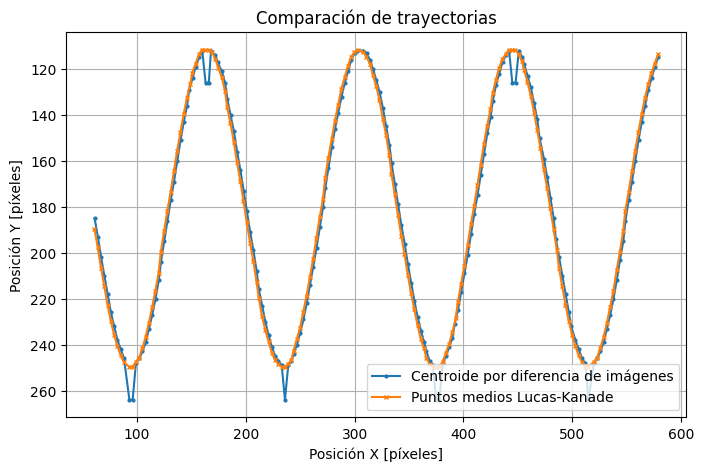

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\trajectory_comparison_synthetic_clean_1.png


In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    comparison_df["frame_difference_x"],
    comparison_df["frame_difference_y"],
    marker="o",
    markersize=2,
    label="Centroide por diferencia de imágenes"
)

plt.plot(
    comparison_df["lucas_kanade_mean_x"],
    comparison_df["lucas_kanade_mean_y"],
    marker="x",
    markersize=3,
    label="Puntos medios Lucas-Kanade"
)

plt.gca().invert_yaxis()
plt.xlabel("Posición X [píxeles]")
plt.ylabel("Posición Y [píxeles]")
plt.title("Comparación de trayectorias")
plt.legend()
plt.grid(True)
plt.savefig(trajectory_comparison_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", trajectory_comparison_plot)

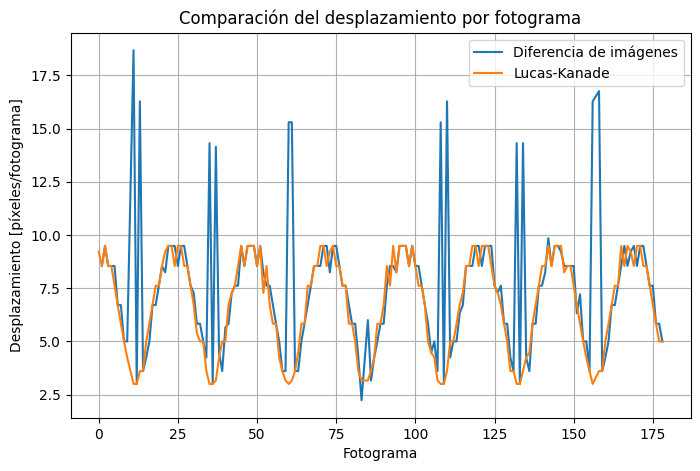

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\displacement_comparison_synthetic_clean_1.png


In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    comparison_df["frame"],
    comparison_df["frame_difference_displacement"],
    label="Diferencia de imágenes"
)

plt.plot(
    comparison_df["frame"],
    comparison_df["lucas_kanade_displacement"],
    label="Lucas-Kanade"
)

plt.xlabel("Fotograma")
plt.ylabel("Desplazamiento [píxeles/fotograma]")
plt.title("Comparación del desplazamiento por fotograma")
plt.legend()
plt.grid(True)
plt.savefig(displacement_comparison_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", displacement_comparison_plot)

## Resultado

La diferencia de imágenes estima la posición de la región móvil mediante el centroide del contorno detectado. Este método permite obtener una trayectoria aproximada del objeto, aunque puede presentar saltos si la región detectada cambia de forma brusca entre fotogramas.

Lucas-Kanade no detecta el objeto completo, sino que sigue puntos característicos. Por ello, la trayectoria media de sus puntos puede ser más estable, pero depende de que el objeto tenga textura, bordes o detalles internos.

Esta comparación muestra que ambos métodos proporcionan información distinta sobre el movimiento: la diferencia de imágenes trabaja sobre regiones móviles, mientras que Lucas-Kanade trabaja sobre puntos concretos.